# Tweet Sentiment Analysis using NLP

## Business Understanding
Titan Electronic Company is a company that retails high-end products such as iPhones, iPads and other premium electronic products. It operates in a quite competititive market where customer perception directly influences sales, brand loyalty and market share. Because the products they sell are quite expensive, customers often tend to be very expressive and critical about their experience using the said products.

Social media platforms like X(Twitter) is one of the major platforms where the customers channel their feedback publicly, making it a very valuable source of real-time data for Titan Electronic Company. However, the company cannot analyze the tens of thousands of comments from the various social media platforms since this will be expensive, impractical and inefficient.

To address this challenge, Titan Electronic requires an automated NLP model that will help them classify the tweets into Negative, Positive or Neutral sentiments. By filtering out irrelevant banter in tweets, the **marketing, customer Support, Product, Public Relations(PR), Sales and Management Team** can quickly pick consumer trends and mitigate any impending negative pubicity and also leverage on positive sentiment while maintaining a ompetitive edge and sare in the market.

## Problem statement
Titan Electronic faces the challenge of tracking customer sentiments due to the overwhelmiing number of tweets they receive. **The company therefore needs to develop a robust sentiment analysis model capable of accurately classifying the emotions accurately from the noisy text.** The tweets also present challenges that may hinder model performance as the tweets also have slang, punctuations, sarcasm, abbreviations and class imbalance. 

Therefore, the company's real problem is to build an effective system that can extract meaningful insights, and allow the company monitor customer sentiments and improve their decision making.


## Business Objectives
The main objectives of the project is to build an automated machine learning that will be able to classify the tweets as begative, positive, or neutral:
- Understand customers opinion and emotions towards the products/brand
- Monitor brand reputation in real time from tweets in their Twitter page
- Support data driven decision making in product development and marketing by identifying customer trends to optimize and guide marketing strategy
- Develop a model that can handle large volumes of tweets

## Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.stem import WordNetLemmatizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from collections import Counter
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AbigaelKariuki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AbigaelKariuki\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Data Understanding
The dataset contains tweets about iPhone, Google and Apple products from customers. Each row represents a single tweet made by a customer.

- **tweet text**: contents of the tweet
- **emotion_in_tweet_is_directed_at**: brand or product of which the tweet is about.
- **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

Undestanding the contents of the tweets and what the columnns entail is crucial before any preprocessing is done.

In [3]:
# Loading the dataset
df = pd.read_csv('../data/judge_1377884607_tweet_product_company.csv', encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [4]:
df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,8720,3169,8721
unique,8693,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,910,5156


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8721 entries, 0 to 8720
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          8720 non-null   object
 1   emotion_in_tweet_is_directed_at                     3169 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  8721 non-null   object
dtypes: object(3)
memory usage: 204.5+ KB


In [6]:
df.shape

(8721, 3)

## Observations and reasons on how data will be cleaned.
We loaded the dataset **judge-1377884607_tweet_product_company.csv** and inspected its structure, shape and the datatype it contained.

**Shape and Data types**
The dataset contains 9,093 rows and 3 columns
 - **tweet text**: contents of the tweet
 - **emotion_in_tweet_is_directed_at**: brand ot product of which the tweet is about
 - **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

**Missing values**
 - **tweet text** column has only ***one** missing value. The missing value will be dropped

 - **emotion_in_tweet_is_directed_at** column has **5,802 missing values** . We will not drop the missing values because the metadata from that column is optional and therefore won't be used. Since the missing values and over 60%, dropping them could ultimately affect model training

 - **is_there_an_emotion_directed_at_a_brand_or_product** column has no missing values

 **Duplicates**
  - There are 27 duplicate rows in the dataset. These will be dropped to prevent the model from learning repetitive data.

**Accuracy of sentiment labels**
 - The sentiment columns contains the following labels **negative emotion**, **positive emotion**, and **neutral emotion towards the brand or product**
  - The is one label **"I can't tell "** which will be dropped. This is because label is ambiguous and does not provide a clear sentiment. Keeping it may introduce noice to the model which might reduce model performance.

In [7]:
df.isnull().sum() ## check for null entries

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5552
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [8]:
# dealing with the missing values. Do we drop of fill?
# for tweet, we will drop that one missing value

df = df.dropna(subset=['tweet_text']) # dropped the one missing tweet
df.isnull().sum() 

tweet_text                                               0
emotion_in_tweet_is_directed_at                       5551
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [9]:
# Duplicates
duplicates = df['tweet_text'].duplicated().sum()  # check for duplicates in the 'tweet' column
print(f"Duplicate tweets: {duplicates}")
df = df.drop_duplicates(subset='tweet_text').reset_index(drop=True) # drop duplicates based on the 'tweet' column and reset index
print(f"Shape after removing duplicates: {df.shape}")

Duplicate tweets: 27
Shape after removing duplicates: (8693, 3)


In [10]:
## Normalizing sentiment labels and removing "I can't tell" entries
df['is_there_an_emotion_directed_at_a_brand_or_product'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].str.lower().str.strip()
df = df[df['is_there_an_emotion_directed_at_a_brand_or_product'] != "i can't tell"]

print(f"Shape after removing ambiguous labels: {df.shape}")
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

Shape after removing ambiguous labels: (8542, 3)
no emotion toward brand or product    5139
positive emotion                      2859
negative emotion                       544
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64


## Data Preparation
In this stage, we will prepare the tweet for NLP modelling. The steps will include: 

1. **Lemmatization**- examining the morphology of the words and reducing each word to its most basic form or lemma eg studies become study.

2. **Lowercasing**- reducing the number of unique words words the model must handle, improving model consistency and ensuring the model learns **all occurences of a word together**, and simplifies **text processing**

3. **Tokenization and removing stopwords**-splitting the sentences into array of individual words. Stopwords(common words or pretty useless data) that contain litte or no information.

4. **Label Encoding**-a simple and very common technique in Machine Learning to convert **categorical labels**(text) into **numbers**.

5. **Stemming**- sremoval of suffixes in words eg cats to cat.


### Text Cleaning Function

In [11]:
## Mapping the product names to their respective brands

apple_list = [x.lower() for x in ['iPad', 'Apple', 'iPad app', 'iPhone app', 'iPhone', 'Mac', 'MacBook']]
google_list = [x.lower() for x in ['Google' , 'Android App', 'Android']]

def map_to_brand(product_name):
    if pd.isna(product_name):
        return None
    
    product_name = str(product_name).lower()
    
    if product_name in apple_list:
        return 'Apple'
    elif product_name in google_list:
        return 'Google'
    else:
        return None

df['product'] = df['emotion_in_tweet_is_directed_at'].apply(map_to_brand)

def fill_missing_product(row):
    if pd.notna(row['product']):
        return row['product']
    
    text = str(row['tweet_text']).lower()
    
    if any(word in text for word in ['apple', 'ipad', 'iphone', 'mac']):
        return 'Apple'
    elif any(word in text for word in ['google', 'android', 'pixel']):
        return 'Google'
    else:
        return 'Not specified'

df['product'] = df.apply(fill_missing_product, axis=1)

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_clean_tokens(text):
    if not isinstance(text, str):
        return []
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtag symbols (keep the word)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stop words
    
    tokens = [word for word in tokens if word not in stop_words]
    # Remove short tokens (1-2 chars)
    tokens = [t for t in tokens if len(t) > 2]
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

In [13]:
## Apply the cleaning function to the 'tweet_text' column and create a new column 'clean_text'

df['clean_text'] = df['tweet_text'].apply(lambda x: " ".join(get_clean_tokens(x)))

df[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iphone hr tweeting riseaustin dead need upgrad...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,hope year festival isnt crashy year iphone app...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri sxsw marissa mayer google tim ...


In [14]:
positive_emotion = []
negative_emotion = []


for text, is_there_an_emotion_directed_at_a_brand_or_product in zip(df['tweet_text'], df['is_there_an_emotion_directed_at_a_brand_or_product']):
    tokens = get_clean_tokens(text)
    if is_there_an_emotion_directed_at_a_brand_or_product == 'Positive emotion':
        positive_emotion.extend(tokens)

    elif is_there_an_emotion_directed_at_a_brand_or_product == 'Negative emotion':
        negative_emotion.extend(tokens)

# Top 15 Positive tweets
print("\n=== Top 15 Words in POSITIVE Sentiment ===")
print(Counter(positive_emotion).most_common(15))

# Top 15 Negative tweets
print("\n=== Top 15 Words in NEGATIVE Sentiment ===")
print(Counter(negative_emotion).most_common(15))


=== Top 15 Words in POSITIVE Sentiment ===
[]

=== Top 15 Words in NEGATIVE Sentiment ===
[]


## Defining Feature and Target variable

Below, we define the Feature(X) and Target(y) variables

In [15]:
X = df['clean_text']
y = df['is_there_an_emotion_directed_at_a_brand_or_product']

### Class Distribution Check
Before we split our data, we examine the distribution of sentiment class. This will help us confrm whethe there exists a class balance and infrm ur choice of modelling strategy.

Since our dataset is imbalanced, randomly splitting the dataset may cause distortion leading to biased evaluation results. To curb this, we apply a stratified sampling during the train/test split.


In [16]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts(normalize=True) *100

no emotion toward brand or product    60.161555
positive emotion                      33.469913
negative emotion                       6.368532
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: float64

We split the dataset into training and test sets using **80/20** split.

Because the classes are imbalanced, we apply **the stratified sampling** to preserve the original class distribution.

A fixed random state will ensure our data is reproducible.

## Train/Test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Modelling
The goal of this section is to build and compare classification models that can accurately predict sentiment from tweet text.

Pipelines will be used in modelling to ensure ther is no **data leakage**

## Baseline Model
### Logistic Regression + TF-IDF
Logistic Regression was chosen as a simple and interpretable linear model suitable for text classification. It will be combined with TF-IDF.  Combining Logistic Regression or Naive Bayes with TF-IDF is a crucial step in sentiment analysis because TF-IDF turns the raw texts into meaningful numerical features that the model can understand. 

TF-IDF converts the tweets into vectors that reflect how important each word is in that tweet relative to the whole corpus. TF-IDF assigns weights to words in our tweets. **Without TF-IDF, the models will treat all words equally hence poor accuracy. TF-IDF helps makes better predictions for importtant words**

**All our models will be combined with TF-IDF**

In [18]:
### Baseline Model = Logistic Regresison with TF-IDF

# Building the full pipeline
pipeline_log= Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier',LogisticRegression())
])

#  training the baseline model
pipeline_log.fit(X_train,y_train)

# predictions
y_pred_baseline = pipeline_log.predict(X_test)

print(f'Baseline Logistic Regression with TFIDF')
print(classification_report(y_test,y_pred_baseline))

print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Baseline Logistic Regression with TFIDF
                                    precision    recall  f1-score   support

                  negative emotion       0.67      0.07      0.13       109
no emotion toward brand or product       0.70      0.88      0.78      1028
                  positive emotion       0.65      0.45      0.53       572

                          accuracy                           0.69      1709
                         macro avg       0.67      0.47      0.48      1709
                      weighted avg       0.68      0.69      0.66      1709

Confusion Matrix
[[  8  80  21]
 [  4 907 117]
 [  0 314 258]]


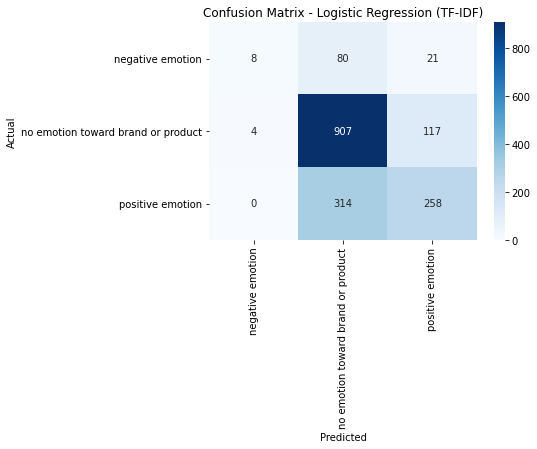

In [19]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)


labels = sorted(y_test.unique())

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Interpretation
**1. Negative Emotion**
  - Precision: 0.75

  - Recall: 0.05
  
  - F1-score- 0.62

  The model performs **poorly on negative sentiment**. Although the predictions are often correct when it does label something as negative, it often rarely identfies negative cases(very low recall). This leads to misclaSsification of the negative instances, meaning the model misses nearly all negative sentiments.

**2. Neutral emotion**
  - Precision: 0.69

  - Recall: 0.87
  
  - F1-score- 0.77

  The model performs **best on neutral sentiment** class with an F1-score of 0.77, driven by high recall(0.87). However, the relatively low precision(0.69) indicates that the model is biased towards predicting the neutral cases, frequently misclassifying both positive and negative tweets as neutral.

**2. Positive emotion**
  - Precision: 0.62

  - Recall: 0.44
  
  - F1-score- 0.51

  The model performed **poorly on the positive emotion** with an F1_score of only 0.51. While precision is moderate(0.62), the recall was very low(0.44), indicating the model failed to capture more than half of the actual positive tweets. More positive senttiments were also incorrectly classified as "no emotion towards brand or product". This suggests a strong bias towards the neutral class, that limits the model ability to detect positive sentiment effectively.

### Baseline-Multinomial Naive Bayes 

In [20]:

# Building the full pipeline
nb_baseline_pipeline= Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb',MultinomialNB(alpha=0.5))
])

#  training the baseline model
nb_baseline_pipeline.fit(X_train,y_train)

# predictions
y_pred_nb_baseline = nb_baseline_pipeline.predict(X_test)

print(f'Baseline Naive Bayes with TFIDF')
print(classification_report(y_test,y_pred_nb_baseline))

#Plotting the confusion matrix for the baseline model
print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Baseline Naive Bayes with TFIDF
                                    precision    recall  f1-score   support

                  negative emotion       0.80      0.04      0.07       109
no emotion toward brand or product       0.68      0.92      0.78      1028
                  positive emotion       0.68      0.37      0.48       572

                          accuracy                           0.68      1709
                         macro avg       0.72      0.44      0.44      1709
                      weighted avg       0.68      0.68      0.63      1709

Confusion Matrix
[[  8  80  21]
 [  4 907 117]
 [  0 314 258]]


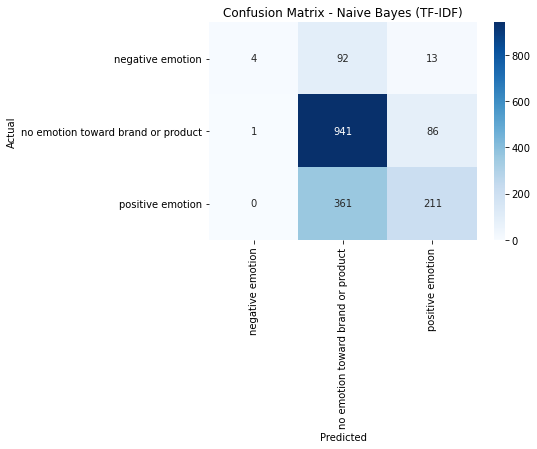

In [21]:
labels = sorted(y_test.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_nb_baseline, labels=labels)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Naive Bayes (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Baseline Naive Bayes Interpretation

**1.Negative Emotion**
  - Precision: 0.75

  - Recall: 0.03(almost all the negatives are missed)
  
  - F1-score- 0.05

  The model performs **poorly on negative sentiment.** Although the predictions are often correct when it does the labelling for something as negative(high precision), it rarely identifies the negative cases(extremely low recall). From the confusion matrix, the model predicts only **3 out 0f 144** correctly. Most negatives predicted as **neutral(91) and positive(20)**. This leads to heavy misclassification, with most negative models being predicted as being neutral showing that the model misses nearly all **negative sentiments**.

  **2.Neutral Emotion**
  - Precision: 0.66

  - Recall: 0.91(very high)- most neutral cases were correctly identified
  
  - F1-score- 0.77

  Model performs **best on the neutral class**, with a very strong F1-score of 0.77 driven by very high recall(0.91). The moderate precision of 0.66 however indicates that the model is biased towards predicting neutral, frequently misclasssifying both negative and positive tweet as neutral.


  **3.Positive Emotion**
  - Precision: 0.62

  - Recall: 0.32(many positives are missed)
  
  - F1-score- 0.42(model sruggles to separate positive from neutral)

  The model **performs poorly on positive sentiment**, with an F1-score of 0.42, moderate precision of 0.62 and recall of 0.32, showing the model fails to capture a large chunk of actual positives. Many positive classes are misclassified, further confirming the model's strong bias towards the neutral class, which limit its ablity to detect positive sentiment correctly. 

### Tweaked Logistic Regression with TF-IDF

In [23]:
# Training our tweaked logistic rgression
tweakedlog_pipeline.fit(X_train,y_train)

# Predicting and evaluating the model
y_pred_baseline = tweakedlog_pipeline.predict(X_test)

print(f'Tweaked Logistic Regression with TF-IDF')
print(classification_report(y_test,y_pred_baseline))

# plotting confusion matrix for the improved baseline model
print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Tweaked Logistic Regression with TF-IDF
                                    precision    recall  f1-score   support

                  negative emotion       0.31      0.50      0.38       109
no emotion toward brand or product       0.76      0.71      0.74      1028
                  positive emotion       0.58      0.58      0.58       572

                          accuracy                           0.65      1709
                         macro avg       0.55      0.60      0.56      1709
                      weighted avg       0.67      0.65      0.66      1709

Confusion Matrix
[[ 54  29  26]
 [ 82 730 216]
 [ 40 199 333]]


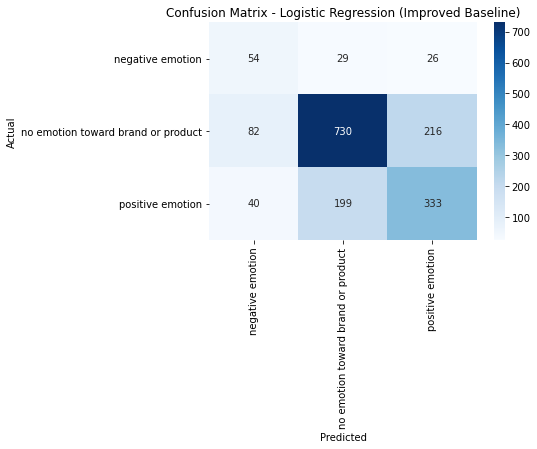

In [24]:

labels = sorted(y_test.unique())


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline, labels=labels)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Logistic Regression (Improved Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Tweaked Logistic Regression interpretation

**1.Negative Emotion**
  - Precision: 0.33

  - Recall: 0.54
  
  - F1-score- 0.41

The models shows improvement on detecting negative sentiment compared to its baseline model, with a recall of 0.54. It correctly identified **62 out of 114** negative cases. However, the precision is low(0.33), indicating many non-negative instances incorrectly labeled as negative. From the confusion matrix, **76 tweets were classified as neutral and 49 tweets** were misclassified as negative, showing the model tends to over-predict this class.


**2.Neutral Emotion**
  - Precision: 0.78

  - Recall: 0.70
  
  - F1-score- 0.73

Model performs well on the neutral class with a better balance of precision and recall. It correctly classifies **748 out of 1074 neutral tweets.** However, some **250 neutral tweets were misclassified as positive** and **76 as negative** indicating an overlap between the classes. 

**3.Positive Emotion**
  - Precision: 0.58

  - Recall: 0.61
  
  - F1-score- 0.59

  The model performs moderately better on positive sentiment. It further correctly identifies **364 out of 594** positive tweets.  However, it misclassifies a significant number **181** as neutral tweets and some as negative **(49)**, suggesting that the model does struggle to separate positive sentiment from the other class.

  The model is somehow more balanced and sensitive to all sentiments, although it still struggles to separate the neutral and positive instances, and tends to **over-predict negatie sentiment**

### Tweaked version of Naive Bayes with TF-IDF

In [25]:
nb_pipeline = Pipeline([
    ('tidf',TfidfVectorizer(
        max_features=10000,
        ngram_range = (1,2), 
        min_df=2
        )),

    ('nb',MultinomialNB(alpha=0.5))
])

#Training Naive Bayes
nb_pipeline.fit(X_train,y_train)

#Predictions
y_pred_nb= nb_pipeline.predict(X_test)

#printing clasification report for Naives Bayes
print(f'Tweaked Naive Bayes with TF-IDF')
print(classification_report(y_test, y_pred_nb))

# plotting confusion matrix for Naive Bayes
print(f'Confusion Matrix(Tweaked Naive Bayes with TF-IDF):')
print(confusion_matrix(y_test,y_pred_nb))

Tweaked Naive Bayes with TF-IDF
                                    precision    recall  f1-score   support

                  negative emotion       0.75      0.06      0.10       109
no emotion toward brand or product       0.68      0.88      0.77      1028
                  positive emotion       0.63      0.40      0.49       572

                          accuracy                           0.67      1709
                         macro avg       0.69      0.45      0.45      1709
                      weighted avg       0.67      0.67      0.63      1709

Confusion Matrix(Tweaked Naive Bayes with TF-IDF):
[[  6  86  17]
 [  2 905 121]
 [  0 341 231]]


<AxesSubplot:>

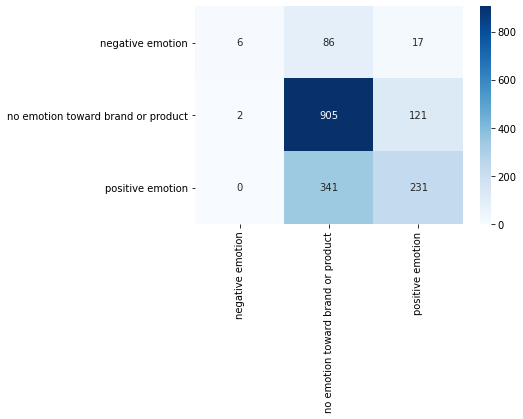

In [26]:

labels = sorted(y_test.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_nb, labels=labels)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

### Model interpretation-Naive Bayes with TF-IDF
**1.Negative Emotion**
  - Precision: 0.83

  - Recall: 0.04
  
  - F1-score- 0.04
  The model shows extremely high precision but very poor recall for negative emotions. Although its confident in predicting the negative instances(83% precision), it correctly identifies **5 out of 114** negative cases(recall=0.04). The model is extremely conservative in predicting negative sentiment but misses the vast majority of the actual negative tweets.

**2.Neutral Emotion**
  - Precision: 0.67

  - Recall: 0.89
  
  - F1-score- 0.77

Model performs best on the neutral class with a strong F1-score of 0.77. It correctly identifies **951 out of 1074** neutral instances(recall 0f 0.89). However, precision is moderate, as many non-neutral tweets(especially positive ones) are being misclassfied as neutral. From the confusion matrix, **368 positive and 90 negative tweets** were misclassified and labelled as neutral.


**3.Positive Emotion**
  - Precision: 0.62

  - Recall: 0.38
  
  - F1-score- 0.47
  
  The model shows moderate precision but low recall for positive emotion. It correctly classifies **226 out of 594** as positive instances. A significant number of positive tweets(368) are misclassified as neutral, indicating the model has a hard time separating positive sentiment ffrom neutral and tends to gravitate to the neutral class.


## Evaluation
Summary comparison of all models. To determine the best model, we will compare the models performance in relation to our business objectives.

Since our dataset has a class-imbalance with neutral class dominating and negative tweets, we focus on:

Our primary business objective is to correctly identify negative sentiment since negative sentiments could expose Titan Electronic to bad publicity and inventory risk. 

Our modelhs particular emphasis on:
 - Detective **negative sentiment early** to mitigate reputational risk
 - Avoid excessive **false positives** that might mislead the marketing and operations team.
 - Consistenly deliver stable performance when handling large vilumes of neutral and positive tweets.

In [37]:
from tabulate import tabulate

In [38]:
results = [
    {
        "Model": "Logistic Regression (Baseline + TF-IDF)",

        # Negative
        "Neg precision": 0.75,
        "Neg recall": 0.05,
        "Neg f1-score": 0.10,

        # Neutral
        "Neu precision": 0.69,
        "Neu recall": 0.87,
        "Neu f1-score": 0.77,

        # Positive
        "Pos precision": 0.62,
        "Pos recall": 0.44,
        "Pos f1-score": 0.51,
    },

    {
        "Model": "Naive Bayes (Baseline + TF-IDF)",

        # Negative
        "Neg precision": 0.75,
        "Neg recall": 0.03,
        "Neg f1-score": 0.05,

        # Neutral
        "Neu precision": 0.66,
        "Neu recall": 0.91,
        "Neu f1-score": 0.77,

        # Positive
        "Pos precision": 0.62,
        "Pos recall": 0.32,
        "Pos f1-score": 0.42,
    },

    { 
        "Model": "Tweaked Logistic Regression + TF-IDF",

        # Negative
        "Neg precision": 0.33,
        "Neg recall": 0.54,
        "Neg f1-score": 0.41,

        # Neutral
        "Neu precision": 0.78,
        "Neu recall": 0.70,
        "Neu f1-score": 0.73,

        # Positive
        "Pos precision": 0.58,
        "Pos recall": 0.61,
        "Pos f1-score": 0.59,
    },

    {
        "Model": "Tweaked Naive Bayes + TF-IDF",

        # Negative
        "Neg precision": 0.83,
        "Neg recall": 0.04,
        "Neg f1-score": 0.08,

        # Neutral
        "Neu precision": 0.67,
        "Neu recall": 0.89,
        "Neu f1-score": 0.77,

        # Positive
        "Pos precision": 0.62,
        "Pos recall": 0.38,
        "Pos f1-score": 0.47,
    }
]

print(tabulate(results, headers="keys",tablefmt="grid"))

+-----------------------------------------+-----------------+--------------+----------------+-----------------+--------------+----------------+-----------------+--------------+----------------+
| Model                                   |   Neg precision |   Neg recall |   Neg f1-score |   Neu precision |   Neu recall |   Neu f1-score |   Pos precision |   Pos recall |   Pos f1-score |
+=========================================+=================+==============+================+=================+==============+================+=================+==============+================+
| Logistic Regression (Baseline + TF-IDF) |            0.75 |         0.05 |           0.1  |            0.69 |         0.87 |           0.77 |            0.62 |         0.44 |           0.51 |
+-----------------------------------------+-----------------+--------------+----------------+-----------------+--------------+----------------+-----------------+--------------+----------------+
| Naive Bayes (Baseline + TF-I

## Trade-Off Analysis
- **Baseline Logistic Regression(TF-IDF)** achieves a poor performance on negative sentiment with a recall of only 0.05 and F1-score of 0.10 indicaing it barely detects any negative tweets and is heavily biased towards the neutral class.


- **Baseline Naive Bayes(TF-IDF)** performs even worse o negative sentiment, recording an extremely low recall of 0.03 and F1-scoreOF 0.05, making it almost ineffective at identifying negative feedback despite high precision when it does predict negative.

- **Tweaked Logistic Regression(TF-IDF)** shows the best improvement on negative sentiment among all models, achieving a recall of 0.54 and F1-cire of 0.41. While it detects more than half of the negative cases, the low precision(0.33) results in many false positives.

- **Tweaked Naive Bayes(TF-IDF)** continues to struggle severely on negative sentiment with a recall of just 0.04 and F1-score of 0.08, remaining overly conservative and strngly biased toward predicting neutral similar to its baseline version.

The results highligha key operational tradeoff between **operation efficiency(precision)** and **sensitivity to risk(recall)**

## Final Recommendation
**Tweaked Regression +TF-IDF**
This is the model recommended for deployment because:
 - it offers the strongest performance for detecting sentiment with the perfect balance between recall(0.54) and F1-score(0.41) which will help in early detection of negative customer feedback, customer retention and reputation management.

 - Compared to the other models, it's superior in catching negative sentiments compared to the other models.

 This model will provide the highest business value for Titan Electronic by helping the marketing, product, Customer Support, Data Analytics, Public Relations.,sales, and management team proactively address customer concerms before they escalate.



## The End!